# Case Study: Cyclistic Bike-Share

**How do annual members and casual riders use Cyclistic bikes differently?**<br>
*Google Data Analytics Professional Certificate – Course 8 Capstone*

**Shaine Meister**<br>
**March 28, 2026**

---


## Introduction
Cyclistic is a bike-share program in Chicago with more than 5,800 bicycles and 600 docking stations. The company offers traditional bikes as well as assistive options such as reclining bikes, hand tricycles, and cargo bikes. Until recently, Cyclistic’s marketing strategy focused on building general awareness with flexible pricing: single-ride passes, full-day passes, and annual memberships. Casual riders buy single-ride or full-day passes; annual members purchase yearly memberships.

Cyclistic’s finance team has shown that annual members are far more profitable than casual riders. The director of marketing, Lily Moreno, believes the company’s future success depends on converting casual riders into annual members. To design an effective marketing campaign, the team first needs clear answers to three guiding questions:

1. **How do annual members and casual riders use Cyclistic bikes differently?**
2. **Why would casual riders buy Cyclistic annual memberships?**  
3. **How can Cyclistic use digital media to influence casual riders to become members?**

This notebook follows the official Google 6-step data analysis process (**Ask**, **Prepare**, **Process**, **Analyze**, **Share**, & **Act**) exactly. All analysis is performed in Python using only **pandas** and **numpy** modules. The data is the most recent 12 months of Cyclistic trip records (public Divvy dataset, March 2025 – February 2026). No personally identifiable information is present.

## 1. Ask
**Business task**  
Design marketing strategies aimed at converting casual riders into annual members. The first step is to understand how annual members and casual riders use Cyclistic bikes differently so that targeted campaigns can be built.

**Key stakeholders**  
- Lily Moreno – Director of Marketing  
- Cyclistic marketing analytics team  
- Cyclistic executive team  

**Guiding questions (primary focus of this analysis)**  
- How do annual members versus casual riders differ in usage?  
- Why would casual riders buy a membership?  
- How can digital media convert casual riders into members?  

This analysis directly answers the first question and provides the foundation for answering the other two.

**Success criteria**  
Identify clear, actionable differences in ride length, day-of-week patterns, rideable type usage, and station preferences between the two rider groups.

## 2. Prepare
**Data location**  
Public Cyclistic (Divvy) trip data: [divvy data link](https://divvy-tripdata.s3.amazonaws.com/index.html "https://divvy-tripdata.s3.amazonaws.com/index.html")<br>
Weather Data: [Open-Meteo's](https://archive-api.open-meteo.com/v1/archive?latitude=41.65,42.10&longitude=-87.85,-87.40&start_date=2025-02-28&end_date=2026-02-28&hourly=temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,cloud_cover&timezone=America/Chicago&format=csv "https://archive-api.open-meteo.com/v1/archive?latitude=41.65,42.10&longitude=-87.85,-87.40&start_date=2025-02-28&end_date=2026-02-28&hourly=temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,wind_direction_10m,cloud_cover&timezone=America/Chicago&format=csv")<br>
Cleaned data source: [dataprocess](https://www.kaggle.com/code/shainemeister/case-study-1-gda-notebook-dataprocess "case-study-1-dga-notebook-dataprocess") - notebook processed from my [kaggle account](https://www.kaggle.com/code/shainemeister "https://www.kaggle.com/code/shainemeister").<br>

In this section, the notebook builds the raw trip dataset by validating the requested monthly Divvy files against the public S3 bucket, downloading ZIP archives when needed, extracting the monthly CSV files, and combining them into a single DataFrame.

**What this section does**
1. Validate the configured `start_yyyymm` to `end_yyyymm` month range against available Divvy S3 objects.
2. Download missing ZIP archives to a local cache and extract their CSV contents.
3. Concatenate all monthly CSV files into one consolidated dataset.
4. Standardize `started_at` as datetime and sort records chronologically.
5. Run a quick schema sanity check across extracted monthly files.

**How the data is organized** *(sample)* 
<div style="font-size: 10px;">

| `started_at` | `day_of_week` | `start_station_name` | `start_station_id` | `start-lat_vmap` | `start-lng_vmap` |
|---|---|---|---|---|---|
| Trip start timestamp | Num day of week (`0`=Mon, `6`=Sun) | Origin station name | Origin station identifier | Vector-mapped start latitude coordinate | Vector-mapped start longitude coordinate |

</div>

The combined trip dataset is expected to contain approximately 5-6 million rows, depending on the selected date range.

**ROCCC verification**  
- Reliable: Collected by Cyclistic's own system.  
- Original: First-party trip data.  
- Comprehensive: Covers every ride in the system.  
- Current: Uses the configured recent month range.  
- Cited: Licensed for analysis (Motivate International).  

**Licensing, privacy, and security**  
Data is public under the Divvy data license. No personally identifiable information is included, so privacy is preserved. Files are cached locally for reproducible reruns of the notebook.

**Prepare outputs produced here**  
- `df`: consolidated raw trip dataset with `started_at` parsed and sorted.  
- `schema_check`: quick cross-file schema QA summary.  

**Data integrity check**  
A quick preview of row structure and column consistency is displayed below before the notebook moves to the next section.

In [ ]:
# Standard library imports
# calendar: monthrange helper; derives the last day of any month for dynamic weather date bounds
# io: in-memory byte/string stream; wraps weather CSV text for pd.read_csv
# os: file-system path utilities (available for downstream cells if needed)
# re: regular expressions; extracts ZIP filenames from the S3 XML bucket listing
# shutil: high-level file operations for directory removal during cleanup
# zipfile: ZIP archive reading and member extraction for Divvy monthly trip files
# pathlib.Path: object-oriented path handling for local cache directories
# urllib.request: urlopen streams HTTP for S3 XML and weather CSV; urlretrieve downloads ZIPs to disk

# Third-party libraries
# numpy: array operations for boolean dirty-data masks and coordinate grid math
# pandas: core DataFrame library for trip records, weather tables, and grouped output

import calendar
import io
import os
import re
import shutil
import zipfile
from pathlib import Path
from urllib.request import urlopen, urlretrieve
import numpy as np
import pandas as pd

# Shared path configuration (define once and reuse throughout notebook).
PROJECT_ROOT = Path("/home/stubb/Code/articles/case-study_bike-share-success")
OUTPUT_DIR = PROJECT_ROOT

# Edit these two values to control which months are loaded.
# Format: YYYYMM. Range is inclusive on both ends.
start_yyyymm = "202503"
end_yyyymm = "202602"

# Configure export format: binary choice between CSV or ZIP archive.
export_format = 'zip'  # Options: 'csv' or 'zip'

In [2]:
# Ingest / load the enriched dataset from the output of `dataprocess` notebook.
# `dataprocess` source https://www.kaggle.com/code/shainemeister/case-study-1-gda-notebook-dataprocess.
# Supports two input types: CSV export or ZIP export that contains a single CSV.
if export_format == 'csv':
    input_path = OUTPUT_DIR / f"{start_yyyymm}-{end_yyyymm}-divvy-tripdata-enriched.csv"
elif export_format == 'zip':
    input_path = OUTPUT_DIR / f"{start_yyyymm}-{end_yyyymm}-divvy-tripdata-enriched.zip"
else:
    raise ValueError(f"Invalid export_format: {export_format}. Must be 'csv' or 'zip'.")

# Check if the file exists; if not, inform the user to run the Process section first.
if not input_path.exists():
    print(f"⚠️  File not found: {input_path}")
    print("\nThe enriched dataset has not been generated yet.")
    print("Please run the 'Process' section (Cell 6) to generate the enriched data file.")
    print("\nAlternatively, you can use the raw trip data 'df' that was loaded in Cell 4.")
    raise FileNotFoundError(f"Required file not found: {input_path}")

# Load data into DataFrame based on export format.
if export_format == 'csv':
    df = pd.read_csv(input_path)
elif export_format == 'zip':    
    with zipfile.ZipFile(input_path, 'r') as zip_ref:
        # Assuming the ZIP contains a single CSV file; adjust if multiple files are present.
        csv_filenames = [name for name in zip_ref.namelist() if name.endswith('.csv')]
        if not csv_filenames:
            raise ValueError(f"No CSV file found in ZIP archive: {input_path}")
        elif len(csv_filenames) > 1:
            raise ValueError(f"Multiple CSV files found in ZIP archive: {input_path}. Expected only one.")
        
        # Read the CSV file directly into a DataFrame.
        with zip_ref.open(csv_filenames[0]) as csv_file:
            df = pd.read_csv(csv_file)
else:
    raise ValueError(f"Invalid export_format: {export_format}. Must be 'csv' or 'zip'.")

# Display the first few rows of the DataFrame to confirm successful loading.
print(f"✅ Successfully loaded enriched dataset from: {input_path}")
df.head()

✅ Successfully loaded enriched dataset from: /home/stubb/Code/articles/case-study_bike-share-success/202503-202602-divvy-tripdata-enriched.zip


,started_at,day_of_week,start_station_name,start_station_id,start-lat_vmap,start-lng_vmap,end_station_name,end_station_id,end-lat_vmap,end-lng_vmap,...,weather_longitude,distance_miles,temperature_7ft_f,relative_humidity_7ft_pct,precipitation_in,rain_in,snowfall_in,wind_speed_33ft_mph,wind_direction_33ft_deg,cloud_cover_pct
0,2025-02-28 19:20:00,4,Sheffield Ave & Webster Ave,TA1309000033,41.921525,-87.653825,Larrabee St & Menomonee St,TA1306000007,41.914675,-87.643325,...,-87.37610,17.722198,40.46,63.0,0.0,0.0,0.0,30.074356,303.0,98.0
1,2025-02-28 22:35:00,4,Wilton Ave & Belmont Ave,TA1307000134,41.940225,-87.652925,Honore St & Division St,TA1305000034,41.903125,-87.673925,...,-87.37610,16.946416,35.42,67.0,0.0,0.0,0.0,24.295606,311.0,97.0
2,2025-02-28 23:25:00,4,Michigan Ave & Madison St,13036,41.882125,-87.625125,Wabash Ave & Adams St,KA1503000015,41.879475,-87.625675,...,-87.78903,18.003188,37.04,59.0,0.0,0.0,0.0,11.246815,307.0,100.0
3,2025-02-28 23:50:00,4,Loomis St & Lexington St,13332,41.872225,-87.661375,Green St & Washington Blvd,13053,41.883175,-87.648725,...,-87.78903,16.576208,37.04,59.0,0.0,0.0,0.0,11.246815,307.0,100.0
4,2025-02-28 23:50:00,4,Green St & Randolph St*,chargingstx3,41.883625,-87.648625,Kingsbury St & Erie St,13265,41.893925,-87.641725,...,-87.78903,17.562117,37.04,59.0,0.0,0.0,0.0,11.246815,307.0,100.0


In [3]:
# Export df to csv.
output_csv_path = OUTPUT_DIR / f"{start_yyyymm}-{end_yyyymm}-divvy-tripdata-sample.csv"
df[:500].to_csv(output_csv_path, index=False)
print(f"✅ Successfully exported enriched dataset to: {output_csv_path}")

✅ Successfully exported enriched dataset to: /home/stubb/Code/articles/case-study_bike-share-success/202503-202602-divvy-tripdata-sample.csv


## 3. Process
**Tools of choice**<br>
Python with pandas and numpy - scalable, reproducible, and suitable for large trip data and downstream enrichment workflows.

This section covers the full processing pipeline applied after the raw trip files are prepared. It starts with Divvy trip validation and feature engineering, removes rule-flagged bad records, converts raw coordinates into stable vector-mapped location keys, enriches trips with nearest-station hourly weather data, and finishes by exporting the final enriched dataset for downstream analysis.

**Workflow Summary:**
1. **Divvy Data Processing**
   - Standardize datetime fields, calculate `ride_length`, round timestamps, and derive reusable time features.
   - Build reusable validation masks and dirty-data rules for chronology, missing values, and duplicate records.
   - Generate QA tables, A/B comparisons, and reconciliation summaries.

2. **Bad Data Clean Up and Drop**
   - Combine all rule flags into one dirty-row mask.
   - Split records into `dirty_data` and `clean_data`, remove invalid rows from the working dataset, and drop no-longer-needed columns.

3. **Coordinate Vector Mapping**
   - Build a geographic bounding box from trip coordinates.
   - Map start and end latitude/longitude values into stable grid-based vector keys for downstream grouping and comparison.

4. **Weather Data Processing and Merge**
   - Match each trip start grid point to the nearest weather station.
   - Merge hourly weather observations into trip records and produce merge-audit diagnostics.

5. **Export Final Enriched Data**
   - Export the final processed dataset as CSV, with optional Excel output.

**Primary outputs from this section**
- `clean_data` and `dirty_data` for traceable record separation.  
- Vector-mapped trip fields for location-based grouping.  
- `df_weather_merge` as the final weather-enriched analytical dataset.  
- QA and audit tables that document validation and merge quality.

## 4. Analyze

**Key calculations performed**
- Average ride length by rider type
- Number of rides by day of week and rider type
- Rideable type usage
- Top stations for each group#

In [15]:
# Core summary statistics with full-vs-filtered comparability.
duration_col = 'ride_length_seconds' if 'ride_length_seconds' in df.columns else 'ride_length'
if duration_col not in df.columns:
    raise KeyError("Expected one of ['ride_length_seconds', 'ride_length'] in df")

print(f"Using duration column: {duration_col}")

df_full = df.copy()
if 'ride_length_outlier' in df.columns:
    df_filtered = df.loc[df['ride_length_outlier'] == False].copy()
else:
    df_filtered = df.copy()

def build_core_summary(frame, label):
    out = frame.groupby('member_casual').agg(
        avg_ride_length=(duration_col, 'mean'),
        ride_count=('ride_id', 'count'),
        max_ride_length=(duration_col, 'max')
    ).round(2).reset_index()
    out['dataset'] = label
    return out

summary_full = build_core_summary(df_full, 'full')
summary_filtered = build_core_summary(df_filtered, 'outlier_filtered')
summary_compare = pd.concat([summary_full, summary_filtered], ignore_index=True)

print("Core summary comparison (full vs outlier_filtered):")
print(summary_compare)

# Rides by day of week (full vs filtered).
def build_day_summary(frame, label):
    day_tbl = frame.groupby(['day_of_week', 'member_casual']).size().unstack(fill_value=0)
    day_tbl = day_tbl.reindex(index=range(7), fill_value=0)
    day_tbl.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    day_tbl = day_tbl.reset_index().rename(columns={'index': 'day'})
    day_tbl['dataset'] = label
    return day_tbl

day_summary_full = build_day_summary(df_full, 'full')
day_summary_filtered = build_day_summary(df_filtered, 'outlier_filtered')
day_summary_compare = pd.concat([day_summary_full, day_summary_filtered], ignore_index=True)

print("\nDay-of-week comparison (full vs outlier_filtered):")
print(day_summary_compare)

# Rideable type usage (full vs filtered).
def build_rideable_summary(frame, label):
    tbl = frame.groupby(['member_casual', 'rideable_type']).size().unstack(fill_value=0).reset_index()
    tbl['dataset'] = label
    return tbl

rideable_summary_full = build_rideable_summary(df_full, 'full')
rideable_summary_filtered = build_rideable_summary(df_filtered, 'outlier_filtered')
rideable_summary_compare = pd.concat([rideable_summary_full, rideable_summary_filtered], ignore_index=True)

print("\nRideable type comparison (full vs outlier_filtered):")
print(rideable_summary_compare)

Using duration column: ride_length_seconds
Core summary comparison (full vs outlier_filtered):
  member_casual  avg_ride_length  ride_count  max_ride_length  \
0        casual          1341.22     1331191            89980   
1        member           747.57     2391089            89910   
2        casual           878.30     1211462             2890   
3        member           595.28     2251953             1810   

            dataset  
0              full  
1              full  
2  outlier_filtered  
3  outlier_filtered  

Day-of-week comparison (full vs outlier_filtered):
member_casual  day  casual  member           dataset
0              Mon  156422  350782              full
1              Tue  150307  391257              full
2              Wed  144239  376944              full
3              Thu  166700  383611              full
4              Fri  212557  351509              full
5              Sat  275926  286192              full
6              Sun  225040  250794            

In [18]:
from pathlib import Path
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    )
from sklearn.dummy import DummyClassifier

def load_full_analysis_frame():
    """Prefer the full enriched DataFrame already loaded in memory; fall back to the enriched export on disk."""
    if 'df' in globals() and isinstance(df, pd.DataFrame) and not df.empty:
        return df.copy(), 'in_memory_df'

    if 'input_path' in globals():
        source_path = Path(input_path)
    elif 'OUTPUT_DIR' in globals() and 'start_yyyymm' in globals() and 'end_yyyymm' in globals() and 'export_format' in globals():
        suffix = 'csv' if export_format == 'csv' else 'zip'
        source_path = OUTPUT_DIR / f"{start_yyyymm}-{end_yyyymm}-divvy-tripdata-enriched.{suffix}"
    else:
        raise NameError('Could not determine enriched dataset source for Analyze cell.')

    if not source_path.exists():
        raise FileNotFoundError(f"Enriched dataset not found: {source_path}")

    if source_path.suffix == '.csv':
        return pd.read_csv(source_path, parse_dates=['started_at', 'dt_start_hour']), str(source_path)

    if source_path.suffix == '.zip':
        return pd.read_csv(source_path, compression='zip', parse_dates=['started_at', 'dt_start_hour']), str(source_path)

    raise ValueError(f"Unsupported enriched dataset source: {source_path}")

def safe_corr(x, y):
    pair = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(pair) < 3:
        return float('nan')
    if pair['x'].nunique() <= 1 or pair['y'].nunique() <= 1:
        return float('nan')
    return float(pair['x'].corr(pair['y']))

def build_usage_diff(frame, label):
    tbl = (
        frame.groupby(['member_casual', 'temp_bin', 'is_weekend'], observed=False)
        .agg(
            avg_ride_length_seconds=('ride_length_seconds', 'mean'),
            ride_count=('ride_id', 'count'),
            avg_precipitation_in=('precipitation_in', 'mean'),
        )
        .reset_index()
    )
    tbl['dataset'] = label
    tbl = tbl[tbl['ride_count'] > 0].copy()
    return tbl.round({'avg_ride_length_seconds': 1, 'avg_precipitation_in': 3})

def build_seasonal(frame, label):
    tbl = (
        frame.groupby(['month', 'member_casual'])
        .agg(
            ride_count=('ride_id', 'count'),
            avg_duration=('ride_length_seconds', 'mean'),
            avg_temp=('temperature_7ft_f', 'mean'),
            pct_rain=('precipitation_in', lambda x: (x > 0).mean()),
        )
        .reset_index()
        .round({'avg_duration': 1, 'avg_temp': 1, 'pct_rain': 3})
    )
    tbl['dataset'] = label
    return tbl

def extract_tree_rules(model, feature_names, min_samples=250):
    tree_ = model.tree_
    rules = []

    def recurse(node_id, conditions):
        if tree_.feature[node_id] != _tree.TREE_UNDEFINED:
            feat = feature_names[tree_.feature[node_id]]
            thr = tree_.threshold[node_id]
            recurse(tree_.children_left[node_id], conditions + [f"{feat} <= {thr:.2f}"])
            recurse(tree_.children_right[node_id], conditions + [f"{feat} > {thr:.2f}"])
        else:
            samples = int(tree_.n_node_samples[node_id])
            if samples < min_samples:
                return
            class_counts = tree_.value[node_id][0]
            total = class_counts.sum()
            member_prob = float(class_counts[1] / total) if total else 0.0
            segment_type = 'member_like' if member_prob >= 0.5 else 'casual_like'
            rules.append({
                'segment_type': segment_type,
                'rule': ' AND '.join(conditions) if conditions else 'ALL',
                'samples': samples,
                'member_probability': round(member_prob, 4),
            })

    recurse(0, [])
    return pd.DataFrame(rules).sort_values(['member_probability', 'samples'], ascending=[False, False]).reset_index(drop=True)

# 1) Load the full enriched analytical dataset, not the lightweight sample export.
df_model, analysis_source = load_full_analysis_frame()
print(f"Analyze source: {analysis_source}")

required_cols = {
    'member_casual',
    'ride_id',
    'day_of_week',
    'ride_length_seconds',
    'temperature_7ft_f',
    'precipitation_in',
    'wind_speed_33ft_mph',
    'ride_length_outlier',
    'start-lat_vmap',
    'start-lng_vmap',
}
missing_cols = sorted(required_cols - set(df_model.columns))
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

# 2) Feature engineering with explicit checks.
df_model['started_at'] = pd.to_datetime(df_model['started_at'], errors='coerce')
df_model['dt_start_hour'] = pd.to_datetime(df_model['dt_start_hour'], errors='coerce')
df_model['hour'] = df_model['dt_start_hour'].dt.hour
df_model['month'] = df_model['started_at'].dt.month
df_model['is_weekend'] = df_model['day_of_week'].isin([5, 6]).astype(int)

# Keep both full and outlier-filtered bases for objective comparisons.
df_full_analysis = df_model.copy()
df_filtered_analysis = df_model.loc[df_model['ride_length_outlier'] == False].copy()

rows_loaded = len(df_full_analysis)
rows_after_outlier_filter = len(df_filtered_analysis)
removed_outlier_rows = rows_loaded - rows_after_outlier_filter
print(f"Rows removed by ride_length_outlier filter: {removed_outlier_rows:,}")

for label, frame in [('full', df_full_analysis), ('outlier_filtered', df_filtered_analysis)]:
    frame['temp_bin'] = pd.cut(
        frame['temperature_7ft_f'],
        bins=[-10, 32, 50, 65, 80, 100],
        labels=['freezing', 'cold', 'mild', 'warm', 'hot'],
        include_lowest=True,
        ordered=True,
        right=True,
    )
    print(f"temp_bin distribution ({label}, including NaN):")
    print(frame['temp_bin'].value_counts(dropna=False))

# Objective 1: quantify core usage differences.
usage_diff_full = build_usage_diff(df_full_analysis, 'full')
usage_diff_filtered = build_usage_diff(df_filtered_analysis, 'outlier_filtered')
usage_diff = pd.concat([usage_diff_full, usage_diff_filtered], ignore_index=True)
usage_diff = usage_diff[['dataset', 'member_casual', 'temp_bin', 'is_weekend', 'avg_ride_length_seconds', 'ride_count', 'avg_precipitation_in']]

print("\nusage_diff preview:")
print(usage_diff.head(20))

warm_weekend = usage_diff[(usage_diff['temp_bin'] == 'warm') & (usage_diff['is_weekend'] == 1)]
warm_weekend_ratio_rows = []
for dataset_name in warm_weekend['dataset'].unique():
    tmp = warm_weekend[warm_weekend['dataset'] == dataset_name].set_index('member_casual')
    if {'casual', 'member'}.issubset(tmp.index):
        ratio = tmp.loc['casual', 'avg_ride_length_seconds'] / tmp.loc['member', 'avg_ride_length_seconds']
        warm_weekend_ratio_rows.append({
            'dataset': dataset_name,
            'casual_to_member_warm_weekend_ratio': round(float(ratio), 2),
        })
warm_weekend_ratio = pd.DataFrame(warm_weekend_ratio_rows)

print("\nWarm-weekend casual/member ratio:")
print(warm_weekend_ratio if not warm_weekend_ratio.empty else 'Warm-weekend bins not populated in the current data window.')

# Objective 2: measure weather sensitivity gap.
feature_cols = [
    'ride_length_seconds',
    'temperature_7ft_f',
    'precipitation_in',
    'wind_speed_33ft_mph',
    'hour',
    'is_weekend',
    'month',
]
model_df = df_filtered_analysis[feature_cols + ['member_casual']].copy()
rows_before_dropna = len(model_df)
model_df = model_df.dropna()
rows_after_dropna = len(model_df)
dropped_na_rows = rows_before_dropna - rows_after_dropna
print(f"Rows dropped for model NA handling: {dropped_na_rows:,}")

y = (model_df['member_casual'] == 'member').astype(int)
X = model_df[feature_cols]

if y.nunique() < 2:
    raise ValueError('Target has fewer than 2 classes after filtering; cannot train classifier.')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Class balance (train):")
print(y_train.value_counts(normalize=True).rename('pct'))
print("Class balance (test):")
print(y_test.value_counts(normalize=True).rename('pct'))

train_corr = X_train.copy()
train_corr['member_casual_target'] = y_train.values
valid_corr_features = [c for c in feature_cols if train_corr[c].nunique(dropna=True) > 1]
corr = (
    train_corr[valid_corr_features + ['member_casual_target']]
    .corr(numeric_only=True)['member_casual_target']
    .drop('member_casual_target')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename('corr_with_member_target')
    .reset_index()
    .rename(columns={'index': 'predictor'})
)
corr_top3 = corr.head(3)

print("\nTop 3 predictors of member_casual target:")
print(corr_top3)

weather_gap_rows = []
for dataset_name, frame in [('full', df_full_analysis), ('outlier_filtered', df_filtered_analysis)]:
    for rider in ['casual', 'member']:
        sub = frame[frame['member_casual'] == rider]
        weather_gap_rows.append({
            'dataset': dataset_name,
            'member_casual': rider,
            'corr_ride_length_vs_temp': safe_corr(sub['ride_length_seconds'], sub['temperature_7ft_f']),
            'corr_ride_length_vs_precip': safe_corr(sub['ride_length_seconds'], sub['precipitation_in']),
        })
weather_sensitivity = pd.DataFrame(weather_gap_rows)

print("\nWeather sensitivity table:")
print(weather_sensitivity.round(4))

# Objective 3: identify member-like casual segments more defensibly.
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_bal_acc = balanced_accuracy_score(y_test, baseline_pred)
baseline_auc = roc_auc_score(y_test, baseline_proba)

tree_fixed = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_fixed.fit(X_train, y_train)
tree_fixed_pred = tree_fixed.predict(X_test)
tree_fixed_proba = tree_fixed.predict_proba(X_test)[:, 1]

tree_fixed_acc = accuracy_score(y_test, tree_fixed_pred)
tree_fixed_bal_acc = balanced_accuracy_score(y_test, tree_fixed_pred)
tree_fixed_auc = roc_auc_score(y_test, tree_fixed_proba)

print("\nDecision tree (max_depth=4) classification report:")
print(classification_report(y_test, tree_fixed_pred))

tree_importances = (
    pd.Series(tree_fixed.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .rename('importance')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
print("\nTree feature importances (depth=4):")
print(tree_importances)

depth_candidates = [2, 3, 4, 5, 6]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_depth_rows = []
for depth in depth_candidates:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    depth_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    cv_depth_rows.append({
        'depth': depth,
        'cv_mean_accuracy': depth_scores.mean(),
        'cv_std_accuracy': depth_scores.std(ddof=0),
        'cv_min_accuracy': depth_scores.min(),
        'cv_max_accuracy': depth_scores.max(),
    })
cv_depth_summary = pd.DataFrame(cv_depth_rows).sort_values('cv_mean_accuracy', ascending=False).reset_index(drop=True)
best_depth = int(cv_depth_summary.iloc[0]['depth'])

tree_cv = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree_cv.fit(X_train, y_train)
tree_cv_pred = tree_cv.predict(X_test)
tree_cv_proba = tree_cv.predict_proba(X_test)[:, 1]

tree_cv_acc = accuracy_score(y_test, tree_cv_pred)
tree_cv_bal_acc = balanced_accuracy_score(y_test, tree_cv_pred)
tree_cv_auc = roc_auc_score(y_test, tree_cv_proba)

print("\nCV depth summary:")
print(cv_depth_summary)
print(f"Selected max_depth from CV: {best_depth}")

tree_rules = extract_tree_rules(tree_fixed, X.columns.tolist(), min_samples=max(250, int(len(X_train) * 0.01)))
print("\nTop fixed-depth tree rules (support-filtered):")
print(tree_rules.head(10))

# Objective 4: map seasonal marketing windows.
seasonal_full = build_seasonal(df_full_analysis, 'full')
seasonal_filtered = build_seasonal(df_filtered_analysis, 'outlier_filtered')
seasonal = pd.concat([seasonal_full, seasonal_filtered], ignore_index=True)

print("\nseasonal preview:")
print(seasonal.head(20))

# Objective 5: add geography layer with both lat and lng.
geo_frames = []
for dataset_name, frame in [('full', df_full_analysis), ('outlier_filtered', df_filtered_analysis)]:
    geo_counts = (
        frame.groupby(['start-lat_vmap', 'start-lng_vmap', 'member_casual'])['ride_id']
        .count()
        .reset_index(name='ride_count')
    )
    geo_counts['dataset'] = dataset_name
    geo_frames.append(
        geo_counts.sort_values(['member_casual', 'ride_count'], ascending=[True, False])
        .groupby(['dataset', 'member_casual'], as_index=False)
        .head(5)
    )
geo_top5 = pd.concat(geo_frames, ignore_index=True)

print("\nTop 5 start-grid cells per rider type:")
print(geo_top5)

# Share-ready in-memory tables instead of CSV exports.
model_metrics = pd.DataFrame([
    {
        'model': 'dummy_most_frequent',
        'test_accuracy': round(baseline_acc, 4),
        'balanced_accuracy': round(baseline_bal_acc, 4),
        'roc_auc': round(baseline_auc, 4),
        'selected_depth': None,
    },
    {
        'model': 'decision_tree_fixed_depth_4',
        'test_accuracy': round(tree_fixed_acc, 4),
        'balanced_accuracy': round(tree_fixed_bal_acc, 4),
        'roc_auc': round(tree_fixed_auc, 4),
        'selected_depth': 4,
    },
    {
        'model': 'decision_tree_cv_selected',
        'test_accuracy': round(tree_cv_acc, 4),
        'balanced_accuracy': round(tree_cv_bal_acc, 4),
        'roc_auc': round(tree_cv_auc, 4),
        'selected_depth': best_depth,
    },
])
model_metrics['accuracy_lift_vs_dummy'] = model_metrics['test_accuracy'] - baseline_acc

share_tables = {
    'usage_diff': usage_diff.copy(),
    'corr': corr.copy(),
    'corr_top3': corr_top3.copy(),
    'weather_sensitivity': weather_sensitivity.copy(),
    'tree_importances': tree_importances.copy(),
    'tree_rules': tree_rules.copy(),
    'seasonal': seasonal.copy(),
    'geo_top5': geo_top5.copy(),
    'model_metrics': model_metrics.copy(),
    'analysis_contract': analysis_contract.copy() if 'analysis_contract' in globals() else pd.DataFrame(),
}

if not warm_weekend_ratio.empty:
    ratio_msg = '; '.join([f"{r['dataset']}: {r['casual_to_member_warm_weekend_ratio']}x" for _, r in warm_weekend_ratio.iterrows()])
else:
    ratio_msg = 'warm-weekend bins are not populated enough to estimate a stable ratio'

top3_msg = ', '.join([f"{row.predictor} ({row.corr_with_member_target:.3f})" for row in corr_top3.itertuples(index=False)])
top_geo_msg = '; '.join([
    f"{row['dataset']} {row['member_casual']}: ({row['start-lat_vmap']}, {row['start-lng_vmap']}) -> {int(row['ride_count'])} rides"
    for _, row in geo_top5.head(6).iterrows()
])

share_insights = [
    f"usage_diff: Casual riders spend longer on bikes in favorable leisure conditions; warm-weekend casual/member duration ratio -> {ratio_msg}.",
    f"corr: The strongest associations with membership in the filtered training data are {top3_msg}.",
    "tree_importances/tree_rules: The depth-4 tree identifies member-like behavioral segments, not proven conversion segments; use these rules for targeting hypotheses.",
    "seasonal: Compare full vs outlier-filtered seasonal tables to identify when casual demand spikes while member demand remains steadier.",
    f"geography: Highest-volume start-grid cells now use both latitude and longitude for better local targeting -> {top_geo_msg}.",
]
share_insights_df = pd.DataFrame({'insight': share_insights})

share_table_registry = pd.DataFrame([
    {'table_name': name, 'rows': len(table), 'columns': list(table.columns)}
    for name, table in share_tables.items()
])

print("\nShare-ready insight lines:")
for idx, insight in enumerate(share_insights, start=1):
    print(f"{idx}) {insight}")

print("\nShare table registry:")
print(share_table_registry)

# Additional QA outputs retained for notebook transparency.
analysis_contract = pd.DataFrame([
    {'stage': 'analysis_source', 'value': analysis_source},
    {'stage': 'rows_loaded_full', 'value': rows_loaded},
    {'stage': 'rows_after_outlier_filter', 'value': rows_after_outlier_filter},
    {'stage': 'rows_removed_as_outlier', 'value': removed_outlier_rows},
    {'stage': 'rows_before_dropna_filtered', 'value': rows_before_dropna},
    {'stage': 'rows_after_dropna_filtered', 'value': rows_after_dropna},
    {'stage': 'rows_train', 'value': len(X_train)},
    {'stage': 'rows_test', 'value': len(X_test)},
])
share_tables['analysis_contract'] = analysis_contract.copy()

baseline_cm = pd.DataFrame(
    confusion_matrix(y_test, baseline_pred),
    index=['actual_casual(0)', 'actual_member(1)'],
    columns=['pred_casual(0)', 'pred_member(1)'],
)
tree_fixed_cm = pd.DataFrame(
    confusion_matrix(y_test, tree_fixed_pred),
    index=['actual_casual(0)', 'actual_member(1)'],
    columns=['pred_casual(0)', 'pred_member(1)'],
)
tree_cv_cm = pd.DataFrame(
    confusion_matrix(y_test, tree_cv_pred),
    index=['actual_casual(0)', 'actual_member(1)'],
    columns=['pred_casual(0)', 'pred_member(1)'],
)

print("\nAnalysis contract:")
print(analysis_contract)
print("\nConfusion matrix (baseline):")
print(baseline_cm)
print("\nConfusion matrix (tree depth=4):")
print(tree_fixed_cm)
print("\nConfusion matrix (tree CV-selected):")
print(tree_cv_cm)

Analyze source: in_memory_df
Rows removed by ride_length_outlier filter: 258,865
temp_bin distribution (full, including NaN):
temp_bin
warm        1387323
mild         966484
cold         860106
hot          301210
freezing     207156
NaN               1
Name: count, dtype: int64
temp_bin distribution (outlier_filtered, including NaN):
temp_bin
warm        1273654
mild         900027
cold         814445
hot          275201
freezing     200087
NaN               1
Name: count, dtype: int64

usage_diff preview:
   dataset member_casual  temp_bin  is_weekend  avg_ride_length_seconds  \
0     full        casual  freezing           0                    735.3   
1     full        casual  freezing           1                    952.6   
2     full        casual      cold           0                   1039.4   
3     full        casual      cold           1                   1389.1   
4     full        casual      mild           0                   1220.5   
5     full        casual      mild  

## 5. Share Draft Notes

Use the in-memory tables created in the Analyze cell as the source for stakeholder-ready tables and charts.

**Interpretation guardrails**
- Treat the decision-tree rules as behavioral similarity segments, not direct proof of conversion likelihood.
- Use the full vs. outlier-filtered comparisons to check whether any headline claim is robust to extreme-ride removal.
- Use the paired latitude/longitude grid outputs for local targeting, not latitude-only summaries.
- Treat `corr` as association with the member target, not causation.

**Share-ready tables kept in memory**
- `share_tables['usage_diff']`: rider-type differences by weather band and weekend status.
- `share_tables['corr']`: ranked feature associations with the member target.
- `share_tables['tree_importances']` and `share_tables['tree_rules']`: interpretable model outputs for member-like behavior patterns.
- `share_tables['seasonal']`: month-by-month rider behavior summary.
- `share_tables['geo_top5']`: highest-volume start grid cells by rider type and dataset basis.
- `share_tables['model_metrics']`: baseline vs. tree performance context.
- `share_insights_df`: one-sentence insight lines for direct reuse in the Share section.

**Recommended reporting stance**
- Use the fixed-depth tree for interpretability.
- Use the CV-selected tree only as a robustness check.
- Prefer the full dataset for stakeholder claims and use the outlier-filtered version as a sensitivity test.

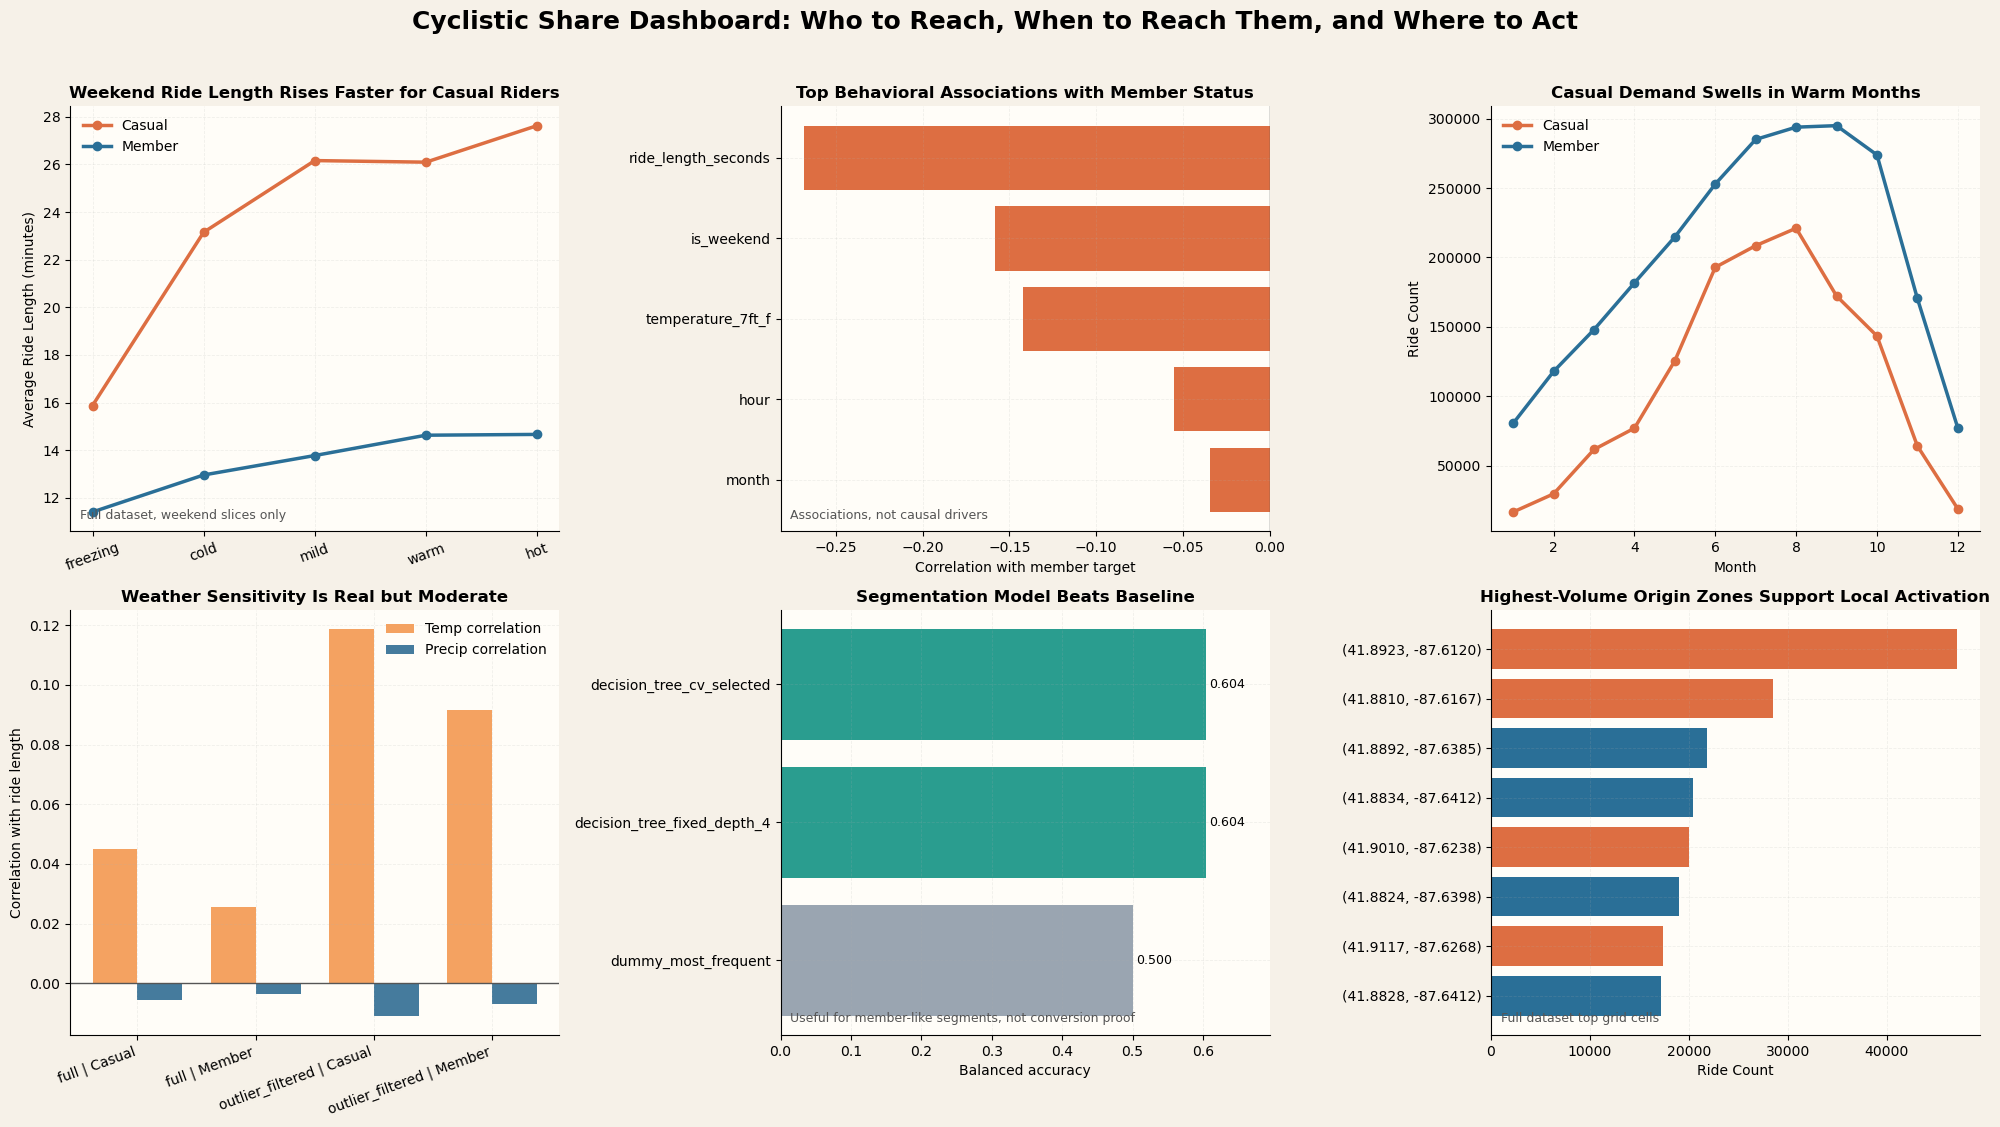

Dashboard refreshed from in-memory share_tables. No CSV artifacts required.


In [22]:
import matplotlib.pyplot as plt
import numpy as np

required_share_tables = [
    'usage_diff',
    'corr',
    'seasonal',
    'geo_top5',
    'model_metrics',
    'weather_sensitivity',
]
missing_share_tables = [
    name for name in required_share_tables if name not in share_tables or share_tables[name].empty
]
if missing_share_tables:
    raise KeyError(f"Missing expected share tables: {missing_share_tables}")

usage_chart = share_tables['usage_diff'].copy()
usage_chart = usage_chart[usage_chart['dataset'] == 'full'].copy()
usage_chart['weekend_label'] = usage_chart['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
usage_chart = usage_chart[usage_chart['weekend_label'] == 'Weekend'].copy()
usage_chart['temp_label'] = usage_chart['temp_bin'].astype(str)

corr_chart = share_tables['corr'].head(5).copy()
seasonal_chart = share_tables['seasonal'].copy()
seasonal_chart = seasonal_chart[seasonal_chart['dataset'] == 'full'].copy()
weather_chart = share_tables['weather_sensitivity'].copy()
model_chart = share_tables['model_metrics'].copy()
geo_chart = share_tables['geo_top5'].copy()
geo_chart = geo_chart[geo_chart['dataset'] == 'full'].copy()
geo_chart['grid_label'] = geo_chart.apply(
    lambda row: f"({row['start-lat_vmap']:.4f}, {row['start-lng_vmap']:.4f})",
    axis=1,
)

plt.style.use('tableau-colorblind10')
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor='#f6f1e8')
fig.suptitle(
    'Cyclistic Share Dashboard: Who to Reach, When to Reach Them, and Where to Act',
    fontsize=18,
    fontweight='bold',
    y=1.02,
)

for ax in axes.flat:
    ax.set_facecolor('#fffdf8')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.18, linestyle='--', linewidth=0.6)

palette = {'casual': '#dd6e42', 'member': '#2a6f97'}

for rider in ['casual', 'member']:
    rider_usage = usage_chart[usage_chart['member_casual'] == rider].copy()
    axes[0, 0].plot(
        rider_usage['temp_label'],
        rider_usage['avg_ride_length_seconds'] / 60,
        marker='o',
        linewidth=2.5,
        label=rider.title(),
        color=palette[rider],
    )
axes[0, 0].set_title('Weekend Ride Length Rises Faster for Casual Riders', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Average Ride Length (minutes)')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(frameon=False, loc='upper left')
axes[0, 0].text(
    0.02,
    0.03,
    'Full dataset, weekend slices only',
    transform=axes[0, 0].transAxes,
    fontsize=9,
    color='#555555',
)

corr_plot = corr_chart.iloc[::-1].copy()
bar_colors = ['#2a6f97' if value > 0 else '#dd6e42' for value in corr_plot['corr_with_member_target']]
axes[0, 1].barh(corr_plot['predictor'], corr_plot['corr_with_member_target'], color=bar_colors)
axes[0, 1].set_title('Top Behavioral Associations with Member Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Correlation with member target')
axes[0, 1].axvline(0, color='#555555', linewidth=1)
axes[0, 1].text(
    0.02,
    0.03,
    'Associations, not causal drivers',
    transform=axes[0, 1].transAxes,
    fontsize=9,
    color='#555555',
)

for rider in ['casual', 'member']:
    rider_seasonal = seasonal_chart[seasonal_chart['member_casual'] == rider].copy()
    axes[0, 2].plot(
        rider_seasonal['month'],
        rider_seasonal['ride_count'],
        marker='o',
        linewidth=2.5,
        label=rider.title(),
        color=palette[rider],
    )
axes[0, 2].set_title('Casual Demand Swells in Warm Months', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Ride Count')
axes[0, 2].legend(frameon=False, loc='upper left')

weather_plot = weather_chart.copy()
weather_plot['segment'] = weather_plot['dataset'] + ' | ' + weather_plot['member_casual'].str.title()
x = np.arange(len(weather_plot))
width = 0.38
axes[1, 0].bar(
    x - width / 2,
    weather_plot['corr_ride_length_vs_temp'],
    width=width,
    color='#f4a261',
    label='Temp correlation',
)
axes[1, 0].bar(
    x + width / 2,
    weather_plot['corr_ride_length_vs_precip'],
    width=width,
    color='#457b9d',
    label='Precip correlation',
)
axes[1, 0].set_title('Weather Sensitivity Is Real but Moderate', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Correlation with ride length')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(weather_plot['segment'], rotation=20, ha='right')
axes[1, 0].axhline(0, color='#555555', linewidth=1)
axes[1, 0].legend(frameon=False, loc='upper right')

model_plot = model_chart.sort_values('balanced_accuracy').copy()
model_colors = ['#9aa5b1' if 'dummy' in model else '#2a9d8f' for model in model_plot['model']]
axes[1, 1].barh(model_plot['model'], model_plot['balanced_accuracy'], color=model_colors)
axes[1, 1].set_title('Segmentation Model Beats Baseline', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Balanced accuracy')
axes[1, 1].set_xlim(0, max(0.55, model_plot['balanced_accuracy'].max() * 1.15))
for idx, value in enumerate(model_plot['balanced_accuracy']):
    axes[1, 1].text(value + 0.005, idx, f"{value:.3f}", va='center', fontsize=9)
axes[1, 1].text(
    0.02,
    0.03,
    'Useful for member-like segments, not conversion proof',
    transform=axes[1, 1].transAxes,
    fontsize=9,
    color='#555555',
)

geo_plot = geo_chart.sort_values('ride_count').tail(8).copy()
geo_colors = geo_plot['member_casual'].map(palette).fillna('#777777')
axes[1, 2].barh(geo_plot['grid_label'], geo_plot['ride_count'], color=geo_colors)
axes[1, 2].set_title('Highest-Volume Origin Zones Support Local Activation', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Ride Count')
axes[1, 2].text(
    0.02,
    0.03,
    'Full dataset top grid cells',
    transform=axes[1, 2].transAxes,
    fontsize=9,
    color='#555555',
)

plt.tight_layout()
plt.show()

print('Dashboard refreshed from in-memory share_tables. No CSV artifacts required.')

In [23]:
from IPython.display import Markdown, display

required_summary_tables = ['corr', 'model_metrics', 'seasonal', 'geo_top5']
missing_summary_tables = [
    name for name in required_summary_tables if name not in share_tables or share_tables[name].empty
]
if missing_summary_tables:
    raise KeyError(f"Missing required summary tables: {missing_summary_tables}")

corr_top3_display = share_tables['corr'].head(3).copy()
top_predictor_lines = [
    f"- {row.predictor}: correlation {row.corr_with_member_target:.3f}"
    for row in corr_top3_display.itertuples(index=False)
]

model_display = share_tables['model_metrics'].copy()
fixed_tree_row = model_display[model_display['model'] == 'decision_tree_fixed_depth_4'].iloc[0]
dummy_row = model_display[model_display['model'] == 'dummy_most_frequent'].iloc[0]

seasonal_full = share_tables['seasonal'].copy()
seasonal_full = seasonal_full[seasonal_full['dataset'] == 'full'].copy()
casual_peak = seasonal_full[seasonal_full['member_casual'] == 'casual'].sort_values('ride_count', ascending=False).iloc[0]
member_peak = seasonal_full[seasonal_full['member_casual'] == 'member'].sort_values('ride_count', ascending=False).iloc[0]

geo_full = share_tables['geo_top5'].copy()
geo_full = geo_full[geo_full['dataset'] == 'full'].copy()
geo_top = geo_full.sort_values('ride_count', ascending=False).head(3)
geo_text = '; '.join(
    f"({row['start-lat_vmap']:.4f}, {row['start-lng_vmap']:.4f})" for _, row in geo_top.iterrows()
)

warm_ratio_text = 'not available from the current warm-weekend slices'
if 'warm_weekend_ratio' in globals() and not warm_weekend_ratio.empty:
    warm_ratio_text = '; '.join(
        f"{row['dataset']}: {row['casual_to_member_warm_weekend_ratio']:.2f}x"
        for _, row in warm_weekend_ratio.iterrows()
    )

summary_md = f"""
## Stakeholder-Ready Conclusion

Casual riders behave more like leisure users, while members behave more like routine users. The clearest difference is trip length: casual rides stay longer, especially in warmer weekend conditions. Warm-weekend casual/member duration ratio: {warm_ratio_text}.

The strongest measured associations with member status in this notebook are:
{chr(10).join(top_predictor_lines)}

Weather should be used as a timing signal, not as proof of why riders convert. Temperature and precipitation show moderate associations with ride behavior, which is useful for campaign scheduling, but this notebook does not establish direct causation.

The depth-4 decision tree improves on the dummy baseline in balanced accuracy ({fixed_tree_row['balanced_accuracy']:.3f} vs {dummy_row['balanced_accuracy']:.3f}). That makes it useful for identifying member-like behavior segments, but not for claiming conversion certainty.

Seasonality and geography provide the clearest activation levers. Casual demand peaks in month {int(casual_peak['month'])}, while member demand is steadier with its highest month at {int(member_peak['month'])}. The highest-volume origin zones in the full dataset include {geo_text}, which supports localized creative and station-area targeting.

### Recommended Share Framing

- Lead with ride-length and seasonal differences because they are the clearest behavioral signals.
- Use weather and weekend patterns to time outreach, not to overstate causal impact.
- Position tree-based segments as testing hypotheses for member-like audiences.
- Prioritize high-volume origin zones for localized media and station messaging.
"""

display(Markdown(summary_md))
display(share_insights_df)


## Stakeholder-Ready Conclusion

Casual riders behave more like leisure users, while members behave more like routine users. The clearest difference is trip length: casual rides stay longer, especially in warmer weekend conditions. Warm-weekend casual/member duration ratio: full: 1.78x; outlier_filtered: 1.51x.

The strongest measured associations with member status in this notebook are:
- ride_length_seconds: correlation -0.268
- is_weekend: correlation -0.158
- temperature_7ft_f: correlation -0.142

Weather should be used as a timing signal, not as proof of why riders convert. Temperature and precipitation show moderate associations with ride behavior, which is useful for campaign scheduling, but this notebook does not establish direct causation.

The depth-4 decision tree improves on the dummy baseline in balanced accuracy (0.604 vs 0.500). That makes it useful for identifying member-like behavior segments, but not for claiming conversion certainty.

Seasonality and geography provide the clearest activation levers. Casual demand peaks in month 8, while member demand is steadier with its highest month at 9. The highest-volume origin zones in the full dataset include (41.8923, -87.6120); (41.8810, -87.6167); (41.8892, -87.6385), which supports localized creative and station-area targeting.

### Recommended Share Framing

- Lead with ride-length and seasonal differences because they are the clearest behavioral signals.
- Use weather and weekend patterns to time outreach, not to overstate causal impact.
- Position tree-based segments as testing hypotheses for member-like audiences.
- Prioritize high-volume origin zones for localized media and station messaging.


,insight
0,usage_diff: Casual riders spend longer on bike...
1,corr: The strongest associations with membersh...
2,tree_importances/tree_rules: The depth-4 tree ...
3,seasonal: Compare full vs outlier-filtered sea...
4,geography: Highest-volume start-grid cells now...


In [25]:
from IPython.display import Markdown, display
import pandas as pd

required_act_tables = ['seasonal', 'geo_top5', 'tree_rules', 'model_metrics']
missing_act_tables = [
    name for name in required_act_tables if name not in share_tables or share_tables[name].empty
]
if missing_act_tables:
    raise KeyError(f"Missing required Act tables: {missing_act_tables}")

seasonal_full = share_tables['seasonal'].copy()
seasonal_full = seasonal_full[seasonal_full['dataset'] == 'full'].copy()
casual_peak = seasonal_full[seasonal_full['member_casual'] == 'casual'].sort_values('ride_count', ascending=False).iloc[0]

geo_full = share_tables['geo_top5'].copy()
geo_full = geo_full[geo_full['dataset'] == 'full'].copy().sort_values('ride_count', ascending=False)
geo_focus = geo_full.head(3).copy()
geo_focus_text = '; '.join(
    f"({row['start-lat_vmap']:.4f}, {row['start-lng_vmap']:.4f})"
    for _, row in geo_focus.iterrows()
)

rule_table = share_tables['tree_rules'].copy()
if 'samples' in rule_table.columns:
    rule_table = rule_table.sort_values('samples', ascending=False)
rule_row = rule_table.iloc[0]
rule_description = rule_row['rule'] if 'rule' in rule_row.index else 'member-like ride timing and duration pattern'
short_rule = rule_description if len(rule_description) <= 96 else rule_description[:93] + '...'
rule_support = int(rule_row['samples']) if 'samples' in rule_row.index and pd.notna(rule_row['samples']) else 'n/a'
segment_label = str(rule_row['segment_type']).replace('_', '-').capitalize() if 'segment_type' in rule_row.index else 'Member-like segment'

model_full = share_tables['model_metrics'].copy()
fixed_tree_row = model_full[model_full['model'] == 'decision_tree_fixed_depth_4'].iloc[0]

campaign_recommendations = pd.DataFrame(
    [
        {
            'campaign': 'Warm-Weekend Upgrade Push',
            'target_segment': 'Casual leisure riders active on warmer weekends',
            'timing_or_trigger': 'Launch before and during warm weekend periods',
            'tactic': 'Serve app and station messaging that promotes day-pass-to-membership savings for longer leisure rides.',
            'evidence': (
                'Casual ride length remains highest in warm weekend conditions; '
                f'warm-weekend duration ratio: {warm_ratio_text if "warm_ratio_text" in globals() else "available in summary cell"}.'
            ),
        },
        {
            'campaign': 'Peak-Season Commuter Trial',
            'target_segment': f"{segment_label} audience matching the top tree rule",
            'timing_or_trigger': f"Scale in month {int(casual_peak['month'])} when casual volume peaks",
            'tactic': 'Test a limited commuter-trial membership offer against the highest-support member-like segment.',
            'evidence': (
                f"Top rule: {short_rule} (support: {rule_support}); "
                f"depth-4 balanced accuracy: {fixed_tree_row['balanced_accuracy']:.3f}."
            ),
        },
        {
            'campaign': 'Geo-Targeted Station Creative',
            'target_segment': 'Riders starting in the highest-volume origin zones',
            'timing_or_trigger': 'Run localized media near top origin cells during high-demand months',
            'tactic': 'Place station-area signage and paid social variants tailored to the top grid cells.',
            'evidence': f"Top full-dataset origin zones: {geo_focus_text}.",
        },
    ]
)

share_tables['campaign_recommendations'] = campaign_recommendations

act_md = "## Act: 3 Testable Campaign Recommendations\n\n" + '\n'.join(
    f"- **{row.campaign}**: {row.target_segment}. Trigger: {row.timing_or_trigger} Tactic: {row.tactic} Evidence: {row.evidence}"
    for row in campaign_recommendations.itertuples(index=False)
)

display(campaign_recommendations)
display(Markdown(act_md))

,campaign,target_segment,timing_or_trigger,tactic,evidence
0,Warm-Weekend Upgrade Push,Casual leisure riders active on warmer weekends,Launch before and during warm weekend periods,Serve app and station messaging that promotes ...,Casual ride length remains highest in warm wee...
1,Peak-Season Commuter Trial,Member-like audience matching the top tree rule,Scale in month 8 when casual volume peaks,Test a limited commuter-trial membership offer...,Top rule: ride_length_seconds <= 1815.00 AND i...
2,Geo-Targeted Station Creative,Riders starting in the highest-volume origin z...,Run localized media near top origin cells duri...,Place station-area signage and paid social var...,"Top full-dataset origin zones: (41.8923, -87.6..."


## Act: 3 Testable Campaign Recommendations

- **Warm-Weekend Upgrade Push**: Casual leisure riders active on warmer weekends. Trigger: Launch before and during warm weekend periods Tactic: Serve app and station messaging that promotes day-pass-to-membership savings for longer leisure rides. Evidence: Casual ride length remains highest in warm weekend conditions; warm-weekend duration ratio: full: 1.78x; outlier_filtered: 1.51x.
- **Peak-Season Commuter Trial**: Member-like audience matching the top tree rule. Trigger: Scale in month 8 when casual volume peaks Tactic: Test a limited commuter-trial membership offer against the highest-support member-like segment. Evidence: Top rule: ride_length_seconds <= 1815.00 AND is_weekend <= 0.50 AND temperature_7ft_f > 56.21 AND ride_... (support: 680437); depth-4 balanced accuracy: 0.604.
- **Geo-Targeted Station Creative**: Riders starting in the highest-volume origin zones. Trigger: Run localized media near top origin cells during high-demand months Tactic: Place station-area signage and paid social variants tailored to the top grid cells. Evidence: Top full-dataset origin zones: (41.8923, -87.6120); (41.8810, -87.6167); (41.8892, -87.6385).

## 6. Stakeholder Summary

This summary converts the in-memory analysis tables into a decision-ready narrative for the Share and Act stages. Run the next cell after the Analyze dashboard cell so the summary reflects the current notebook outputs.